# Import thư viện

In [1]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler    # cho mô hình ML

# GET DATA FROM YAHOO

In [2]:
# # Tải dữ liệu Bitcoin theo giờ (1h)
# coin_df = yf.download("FPT.VN", start="2000-01-01", end="2025-01-01")

# # Giữ lại 5 cột chính (khôFPT.VNAdj Close)
# coin_df = coin_df[['Open', 'High', 'Low', 'Close', 'Volume']].reset_index()

# # Lưu ra CSV mở được trên Excel
# coin_df.to_csv("FPT.VN.csv", index=False, encoding='utf-8-sig')

# Gắn bộ dataset vô đây

In [3]:
df = pd.read_csv(r"D:\kì 3\ADY201m\project_chính thức\VInamilk\Vinamilk_VNM.csv")
df

,Date,Adj Close,Close,High,Low,Open,Volume
0,2023-07-17,61870.484375,72300.0,73600.0,72200.0,73000.0,5802800
1,2023-07-19,62127.210938,72600.0,73000.0,72400.0,72500.0,3025100
2,2023-07-20,62127.210938,72600.0,72800.0,72300.0,72600.0,2600707
3,2023-07-21,62897.378906,73500.0,73500.0,72500.0,72600.0,3821822
4,2023-07-24,62982.957031,73600.0,74000.0,73300.0,73500.0,2535331
...,...,...,...,...,...,...,...
550,2025-10-15,60750.000000,63600.0,64400.0,63600.0,63800.0,4653477
551,2025-10-16,61200.000000,61200.0,61200.0,60200.0,60800.0,5180885
552,2025-10-17,58800.000000,58800.0,61200.0,58800.0,61000.0,6200477
553,2025-10-20,55000.000000,55000.0,59400.0,55000.0,58900.0,8762669


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       555 non-null    object 
 1   Adj Close  555 non-null    float64
 2   Close      555 non-null    float64
 3   High       555 non-null    float64
 4   Low        555 non-null    float64
 5   Open       555 non-null    float64
 6   Volume     555 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 30.5+ KB


# Clean data ---> df_clean.csv


In [5]:
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [6]:
# Chuyển dữ liệu số về numeric
coin_lables = df.columns
for lable in coin_lables:
  if lable != 'Date':
    df[lable] = pd.to_numeric(df[lable], errors = "coerce")

# Drop các dòng có NAN (không hợp lệ/ thiếu )
df.dropna(inplace = True)

# Chuyển cột Date về dạng datetime
df['Date'] = pd.to_datetime(df['Date'])

# Xóa dòng trùng lặp
df.drop_duplicates(inplace = True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       555 non-null    datetime64[ns]
 1   Adj Close  555 non-null    float64       
 2   Close      555 non-null    float64       
 3   High       555 non-null    float64       
 4   Low        555 non-null    float64       
 5   Open       555 non-null    float64       
 6   Volume     555 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 30.5 KB


In [7]:
print('Số giá trị bị NAN : ', df.isnull().sum().sum())

Số giá trị bị NAN :  0


In [8]:
df.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,555,555.000000,555.000000,555.000000,555.000000,555.000000,5.550000e+02
mean,2024-09-06 20:50:35.675675648,59241.642919,65912.252252,66558.018018,65462.162162,66014.594595,3.961535e+06
min,2023-07-17 00:00:00,47971.699219,52000.000000,55200.000000,51400.000000,51400.000000,1.099508e+06
25%,2024-02-17 12:00:00,57500.896484,61550.000000,62200.000000,61200.000000,61850.000000,2.470750e+06
50%,2024-09-09 00:00:00,58744.105469,66100.000000,66600.000000,65800.000000,66200.000000,3.363985e+06
75%,2025-04-01 12:00:00,61268.939453,69550.000000,70450.000000,69000.000000,70000.000000,4.849268e+06
max,2025-10-21 00:00:00,68716.460938,80300.000000,81200.000000,79500.000000,80100.000000,2.156490e+07
std,NaN,3564.649935,5821.154730,5816.935287,5693.372137,5769.506511,2.361230e+06


In [9]:
# Kiểm tra logic OHLC 
mask_invalid  = (df['High'] < df[['Open' , 'Close' , 'Low']].max(axis = 1)) | (df['Low'] > df[['Open' , 'Close' , 'Low']].min(axis = 1))
data_issue_log  = df.loc[mask_invalid , ['Date', 'Open', 'High', 'Low', 'Close']]

data_issue_log

,Date,Open,High,Low,Close


In [10]:
# Kiểm tra giá và khối lượng = 0 --> flag
mask_zero  = (df['Volume'] == 0) | (df[['Open', 'High', 'Low' , 'Close']] == 0).any(axis =1)
data_issue_log  = pd.concat([data_issue_log ,  df.loc[mask_zero , ['Date' , 'Open' , 'High', 'Low', 'Close','Volume']]])

data_issue_log

,Date,Open,High,Low,Close,Volume


In [11]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # ép kiểu
df['gap_days'] = df['Date'].diff().dt.days
missing_days = df[df['gap_days'] > 3][['Date','gap_days']]

missing_days

,Date,gap_days
7,2023-08-03,6.0
28,2023-09-05,5.0
111,2024-01-02,4.0
137,2024-02-15,8.0
188,2024-05-02,6.0
274,2024-09-04,5.0
374,2025-02-03,10.0
419,2025-04-08,4.0
435,2025-05-05,6.0
520,2025-09-03,5.0


Tạo file 

In [12]:
df_clean = df.copy()
df_clean.to_csv('df_clean.csv', index = False)
data_issue_log.to_csv("data_issue_log.csv", index = False)

# Tạo thêm các feature

In [13]:
# Đọc file df_clean 
f = pd.read_csv('df_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop= True)  

CLOSE, OPEN, HIGH, LOW, VOL = 'Close', 'Open', 'High', 'Low', 'Volume'

df['intraday_range'] = df[HIGH] - df[LOW]
df['return'] = df['return'] if 'return' in df.columns else df['Close'].pct_change()
df['volatility_120'] = df['return'].rolling(120, min_periods=120).std()


df['log_return'] = np.log(df[CLOSE] / df[CLOSE].shift(1))
df['range_pct'] = (df['High'] - df['Low']) / df['Close']     # biên độ %
df['close_open_ret'] = (df['Close'] - df['Open']) / df['Open']

# 2) các thống kê rolling (120 ngày liên tiếp )  cột  (volume , return)
win = 120
df['vol_mean'] = df['Volume'].rolling(win).mean()
df['vol_std']  = df['Volume'].rolling(win).std()
df['ret_mean'] = df['return'].rolling(win).mean()
df['ret_std']  = df['return'].rolling(win).std()

df['vol_z'] = (df['Volume'] - df['vol_mean']) / df['vol_std']
df['ret_z'] = (df['return'] - df['ret_mean']) / df['ret_std']

# 3) Tỉ lệ khối lượng so với trung bình (Volume ratio )
df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(30).mean()

# 4)  MA – Moving Average

df['MA_5']  = df['Close'].rolling(5).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

# 5) RSI (14)

delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 6) Bollinger Bands (20, 2σ)

ma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = ma20 + 2 * std20
df['BB_lower'] = ma20 - 2 * std20
df['BB_pos'] = (df['Close'] - ma20) / (2 * std20)  # vị trí giá trong dải BB

# 7) MACD (12, 26, 9)

ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD_line']   = ema12 - ema26
df['MACD_signal'] = df['MACD_line'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD_line'] - df['MACD_signal']

# 8) ATR (14)

tr = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['Close'].shift(1)).abs(),
    (df['Low']  - df['Close'].shift(1)).abs()
], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean()

# 9 ) Chuẩn hóa z-score

for col in ['return','vol_ratio','range_pct','RSI_14']:
    df[col + '_z'] = (df[col] - df[col].rolling(30).mean()) / df[col].rolling(30).std()





 Xử lý NaN & xuất file

In [14]:
df_feat = df.dropna().reset_index(drop=True)
df_feat.to_csv('df_feat.csv', index=False)
print('Write file "df_feat" success')

Write file "df_feat" success


# Phát hiện bất thường theo các quy tắc 

1) Rule-based

In [15]:
import numpy as np
import pandas as pd

df = pd.read_csv("df_feat.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# MA30 của Volume
ma30_vol = df['Volume'].rolling(30, min_periods=30).mean()

# --- 1) Luật (nhạy hơn) ---
df['flag_vol_return'] = (df['vol_ratio'] > 1.8) & (df['return'].abs() > 0.02)

# Vượt BB_upper 1% + Volume > 2 x MA30
df['flag_bollinger'] = (df['Close'] > df['BB_upper'] * 1.002) & (df['Volume'] > 1.2 * ma30_vol)

# --- 2) Z-band nhẹ tay hơn ---
abs_ret_z = df['ret_z'].abs()
vol_z = df['vol_z']

cond_high = ((abs_ret_z >= 1.8) | (vol_z >= 1.8)) & (df['close_open_ret'].abs() >= 0.015)
cond_med  = ((abs_ret_z.between(1.2, 1.8, inclusive='left')) |
             (vol_z.between(1.2, 1.8, inclusive='left')) |
             (df['intraday_range'] >= 0.015))
cond_low  = ((abs_ret_z.between(0.8, 1.2, inclusive='left')) |
             (vol_z.between(0.8, 1.2, inclusive='left')))

df['z_band'] = 'None'
df.loc[cond_low,  'z_band'] = 'Low'
df.loc[cond_med,  'z_band'] = 'Medium'
df.loc[cond_high, 'z_band'] = 'High'

# --- 3) Điểm rule_score (chuẩn hóa 1.2→2.5) ---
z_star = np.maximum(abs_ret_z, vol_z)
df['z_intensity'] = np.clip((z_star - 0.8) / (1.8 - 0.8), 0, 1)

# Thêm
df['flag_rsi_pump'] = (df['RSI_14'] > 70) & (df['vol_ratio'] > 1.5)
df['binary_flags'] = (
    df['flag_vol_return'].astype(int) + 
    df['flag_bollinger'].astype(int) + 
    df['flag_rsi_pump'].astype(int)
) / 3.0

# Nhấn mạnh cờ boole để tăng độ nhạy
df['rule_score'] = 0.35 * df['z_intensity'] + 0.65 * df['binary_flags']

# cho bonus lớn hơn khi có ít nhất 1 flag hoặc High z_band:
bonus = (
    0.15 * ((df['binary_flags'] > 0).astype(float)) +
    0.10 * (df['z_band'] == 'High'))

df['rule_score'] = np.clip(df['rule_score'] + bonus, 0, 1)

cols_keep = [
    'Date','return','vol_ratio','ret_z','vol_z','intraday_range','close_open_ret',
    'flag_vol_return','flag_bollinger','z_band','z_intensity','binary_flags','rule_score'
]
df_rule = df[cols_keep].copy()
df_rule.to_csv("df_rule.csv", index=False)

print("Stage 3 (nhạy hơn) ✅  -> df_rule.csv")
print(df_rule.tail(3))



Stage 3 (nhạy hơn) ✅  -> df_rule.csv
          Date    return  vol_ratio     ret_z     vol_z  intraday_range  \
432 2025-10-17 -0.039216   1.184480 -2.808434  0.471948          2400.0   
433 2025-10-20 -0.064626   1.656804 -4.243175  1.562797          4400.0   
434 2025-10-21  0.027273   1.309141  1.776478  0.819704          1900.0   

     close_open_ret  flag_vol_return  flag_bollinger  z_band  z_intensity  \
432       -0.036066            False           False    High     1.000000   
433       -0.066214            False           False    High     1.000000   
434        0.007130            False           False  Medium     0.976478   

     binary_flags  rule_score  
432           0.0    0.450000  
433           0.0    0.450000  
434           0.0    0.341767  


PHÁT HIỆN BẤT THƯỜNG BẰNG ML (UNSUPERVISED)

In [16]:
# --- 1. Load dữ liệu đặc trưng ---
df = pd.read_csv("df_feat.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# --- 2. Chọn các biến đưa vào mô hình ---
features = [
    'log_return', 'vol_ratio', 'range_pct', 'RSI_14',
    'ret_z', 'vol_z', 'volatility_120', 'MACD_hist', 'BB_pos', 'ATR_14'
]

# ** Chuẩn hóa dữ liệu đầu vào
scaler_in = StandardScaler()
X_scaled = scaler_in.fit_transform(df[features].dropna())


# --- 3. Huấn luyện mô hình IsolationForest ---
iso = IsolationForest(
    n_estimators=500,
    contamination=0.05,     # tỉ lệ dự kiến điểm bất thường
    random_state=42
)

iso.fit(X_scaled)

# --- 4. Tính điểm bất thường (ml_score) ---
# decision_function: càng lớn = càng bình thường → đảo dấu & chuẩn hoá về [0,1]
raw = -iso.decision_function(X_scaled).reshape(-1, 1)
scaler = MinMaxScaler()
df['ml_score'] = scaler.fit_transform(raw)

# --- 5. Xuất kết quả ---
df.to_csv("df_ml.csv", index=False)
print(" Đã tạo cột ml_score trong df_ml.csv")
print(df[['Date', 'ml_score']].tail(10))

 Đã tạo cột ml_score trong df_ml.csv
          Date  ml_score
425 2025-10-08  0.294170
426 2025-10-09  0.052485
427 2025-10-10  0.019976
428 2025-10-13  0.283927
429 2025-10-14  0.060522
430 2025-10-15  0.046527
431 2025-10-16  0.287614
432 2025-10-17  0.463169
433 2025-10-20  0.838193
434 2025-10-21  0.540165


# Ensemble & Gán nhãn

In [17]:
# --- 1. Load dữ liệu ---
df_rule = pd.read_csv("df_rule.csv")   
df_ml   = pd.read_csv("df_ml.csv")     

# Gộp theo Date (tránh lỗi lệch chỉ số)
df_final = pd.merge(df_ml, df_rule[['Date', 'rule_score']], on='Date', how='left')

# --- 2. Ensemble score ---
df_final['anomaly_score'] = 0.4 * df_final['ml_score'] + 0.6 * df_final['rule_score']

# --- 3. Label Yes/No ---
df_final['label'] = np.where(df_final['anomaly_score'] >= 0.4, 'Yes', 'No')

# --- 4. Severity ---
def classify_severity(row):
    abs_ret_z = abs(row.get('ret_z', 0))
    vol_z = row.get('vol_z', 0)
    score = row['anomaly_score']

    if (abs_ret_z >= 3) or (vol_z >= 3) or (score >= 0.75):
        return 'High'
    elif (0.55 <= score < 0.75) or (2 <= abs_ret_z < 3) or (2 <= vol_z < 3):
        return 'Medium'
    elif (0.4 <= score < 0.55) or (1.5 <= abs_ret_z < 2) or (1.5 <= vol_z < 2):
        return 'Low'
    else:
        return 'Normal'

df_final['severity'] = df_final.apply(classify_severity, axis=1)

# --- 5. Xuất kết quả cuối ---
cols_export = ['Date', 'anomaly_score', 'label', 'severity']
df_final.to_csv("df_final_output.csv", index=False)

print(" File  df_final_output.csv   đã tạo")
print(df_final[cols_export].tail(10))


 File  df_final_output.csv   đã tạo
           Date  anomaly_score label severity
425  2025-10-08       0.387668    No   Medium
426  2025-10-09       0.020994    No   Normal
427  2025-10-10       0.007990    No   Normal
428  2025-10-13       0.383571    No      Low
429  2025-10-14       0.024209    No   Normal
430  2025-10-15       0.018611    No   Normal
431  2025-10-16       0.325046    No   Medium
432  2025-10-17       0.455267   Yes   Medium
433  2025-10-20       0.605277   Yes     High
434  2025-10-21       0.421126   Yes      Low


# Gom cụm bất thường & pump-dump

In [18]:

# --- 1) Load dữ liệu ---
final = pd.read_csv("df_final_output.csv")   
feat  = pd.read_csv("df_feat.csv")           

# Đảm bảo Date chuẩn datetime
final['Date'] = pd.to_datetime(final['Date'])
feat['Date']  = pd.to_datetime(feat['Date'])

# Nếu file final không có Close thì merge thêm từ feat
if 'Close' not in final.columns:
    final = pd.merge(final, feat[['Date', 'Close', 'return', 'ret_z', 'vol_z']], on='Date', how='left')
else:
    # Merge thêm các cột còn thiếu (ret_z, vol_z, return)
    if 'ret_z' not in final.columns or 'vol_z' not in final.columns:
        final = pd.merge(final, feat[['Date', 'return', 'ret_z', 'vol_z']], on='Date', how='left')

# --- 2) Tính post_1d / 3d / 5d ---
for n in (1, 3, 5):
    final[f'Close_f{n}'] = final['Close'].shift(-n)
    final[f'post_{n}d']  = (final[f'Close_f{n}'] / final['Close'] - 1.0) * 100.0

# --- 3) Tạo cluster cho label = "Yes" (gap ≤ 1 ngày) ---
yes = final[final['label'] == 'Yes'].copy()
yes['diff_days'] = yes['Date'].diff().dt.days
yes['new_cluster'] = (yes['diff_days'].isna()) | (yes['diff_days'] > 2)
yes['cluster_id'] = yes['new_cluster'].cumsum()

clusters = []
for cid, block in yes.groupby('cluster_id'):
    start_date = block['Date'].iloc[0]
    end_date   = block['Date'].iloc[-1]
    length_days = (end_date - start_date).days + 1

    n_high_days = (block['severity'] == 'High').sum()
    max_vol_z = block['vol_z'].max()
    avg_ret = block['return'].mean() * 100

    # post_xd từ END
    end_idx = block.index[-1]
    post_1d = final.loc[end_idx, 'post_1d']
    post_3d = final.loc[end_idx, 'post_3d']
    post_5d = final.loc[end_idx, 'post_5d']

    # --- 4) Pump–Dump check ---
    pump_dump = 0
    pump_pct = dump_pct = time_to_peak = time_to_dump = np.nan

    # Chỉ kiểm tra nếu trong cụm có vol_z ≥ 2
    if (block['vol_z'] >= 2).any():
        peak_idx = block['Close'].idxmax()
        peak_close = block.loc[peak_idx, 'Close']
        start_close = block['Close'].iloc[0]

        pump_pct = (peak_close / start_close - 1) * 100
        time_to_peak = (block.loc[block['Close'].idxmax(), 'Date'] - start_date).days

        # Tìm dump trong 3 ngày sau peak
        look = final.loc[peak_idx + 1 : peak_idx + 3].copy()
        if not look.empty:
            min_close = look['Close'].min()
            dump_pct = (min_close / peak_close - 1) * 100
            time_to_dump = (look.loc[look['Close'].idxmin(), 'Date'] - block.loc[peak_idx, 'Date']).days
            if dump_pct <= -5:
                pump_dump = 1

    clusters.append({
        'cluster_id': cid,
        'start_date': start_date.date(),
        'end_date': end_date.date(),
        'length_days': length_days,
        'n_high_days': n_high_days,
        'max_vol_z': max_vol_z,
        'avg_ret_%': avg_ret,
        'post_1d_%': post_1d,
        'post_3d_%': post_3d,
        'post_5d_%': post_5d,
        'pump_dump': pump_dump,
        'pump_pct_%': pump_pct,
        'dump_pct_%': dump_pct,
        'time_to_peak_days': time_to_peak,
        'time_to_dump_days': time_to_dump
    })

# --- 5) Xuất kết quả ---
clusters_df = pd.DataFrame(clusters)
clusters_df.to_csv("clusters.csv", index=False)

print("File clusters.csv đã được tạo thành công.")
print(clusters_df.head())


File clusters.csv đã được tạo thành công.
   cluster_id  start_date    end_date  length_days  n_high_days  max_vol_z  \
0           1  2024-02-16  2024-02-16            1            1   6.316634   
1           2  2024-02-19  2024-02-19            1            1   3.161032   
2           3  2024-02-23  2024-02-23            1            0   2.362725   
3           4  2024-02-27  2024-02-29            3            0   2.624224   
4           5  2024-03-08  2024-03-08            1            0   2.969343   

   avg_ret_%  post_1d_%  post_3d_%  post_5d_%  pump_dump  pump_pct_%  \
0   3.550296   2.714286   1.857143   1.428571          0         0.0   
1   2.714286  -0.556328  -0.417246  -1.251739          0         0.0   
2  -0.837989   0.000000   1.690141   0.704225          0         0.0   
3   0.565721  -0.694444   1.388889   0.000000          0         0.0   
4  -2.777778   0.428571   1.142857  -1.714286          0         0.0   

   dump_pct_%  time_to_peak_days  time_to_dump_days  
0 

# Kiểm định và giảm nhiễu

In [19]:
# === Stage 7: Validation & Noise Reduction ===
import pandas as pd
import numpy as np

# --- 1. Load dữ liệu cần thiết ---
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])

# --- 2. SENSITIVITY TEST ---
# Thử các ngưỡng z khác nhau để xem số ngày bất thường thay đổi thế nào
sensitivity = []
for z_th in [2.0, 2.5, 3.0]:
    subset = df[(df['ret_z'].abs() >= z_th) | (df['vol_z'] >= z_th)]
    sensitivity.append({
        'z_threshold': z_th,
        'n_detected_days': len(subset),
        'ratio_detected_%': len(subset) / len(df) * 100
    })
sensitivity_df = pd.DataFrame(sensitivity)

# --- 3. BOOTSTRAP / PERMUTATION TEST ---
np.random.seed(42)
n = len(df)
actual_detected = (df['label'] == 'Yes').sum()
simulations = []

for _ in range(2000):
    shuffled = np.random.permutation(df['anomaly_score'])
    random_yes = (shuffled > 0.4).sum()
    simulations.append(random_yes)

p_value = np.mean(np.array(simulations) >= actual_detected)

# --- 4. MARKET COMPARISON (tùy chọn) ---
# Nếu  chưa có file thị trường (index.csv)
try:
    market = pd.read_csv("index.csv")
    market['Date'] = pd.to_datetime(market['Date'])
    market['index_ret'] = market['Close'].pct_change()
    merged = pd.merge(df, market[['Date','index_ret']], on='Date', how='left')
    merged['market_spike'] = (merged['index_ret'].abs() > 0.02)
    market_overlap = merged[(merged['label']=="Yes") & (merged['market_spike'])].shape[0]
    market_adjusted = actual_detected - market_overlap
    market_comment = f"{market_overlap} anomalies coincide with market-wide moves (|index_ret|>2%)"
except FileNotFoundError:
    market_overlap = np.nan
    market_adjusted = np.nan
    market_comment = "No index.csv provided – skipped market comparison"

# --- 5. Tổng hợp kết quả kiểm định ---
validation_summary = {
    'total_days': len(df),
    'total_anomalies': int(actual_detected),
    'p_value_bootstrap': round(p_value, 4),
    'market_overlap': market_overlap,
    'market_adjusted_anomalies': market_adjusted,
    'market_comment': market_comment,
    'note': "Lower p-value (<0.05) → model anomalies unlikely to occur by chance.",
    'sensitivity_mean_%': round(sensitivity_df['ratio_detected_%'].mean(), 2),
    'sensitivity_range_%': f"{sensitivity_df['ratio_detected_%'].min():.2f}–{sensitivity_df['ratio_detected_%'].max():.2f}"
}

summary_df = pd.DataFrame([validation_summary])
summary_df.to_csv("validation_summary.csv", index=False)

print(" File  validation_summary.csv  đã được tạo.")
print(summary_df)
print("\n--- Sensitivity test ---")
print(sensitivity_df)


 File  validation_summary.csv  đã được tạo.
   total_days  total_anomalies  p_value_bootstrap  market_overlap  \
0         435               42                1.0             NaN   

   market_adjusted_anomalies  \
0                        NaN   

                                      market_comment  \
0  No index.csv provided – skipped market comparison   

                                                note  sensitivity_mean_%  \
0  Lower p-value (<0.05) → model anomalies unlike...                6.36   

  sensitivity_range_%  
0           3.91–9.89  

--- Sensitivity test ---
   z_threshold  n_detected_days  ratio_detected_%
0          2.0               43          9.885057
1          2.5               23          5.287356
2          3.0               17          3.908046


# Trực quan hóa

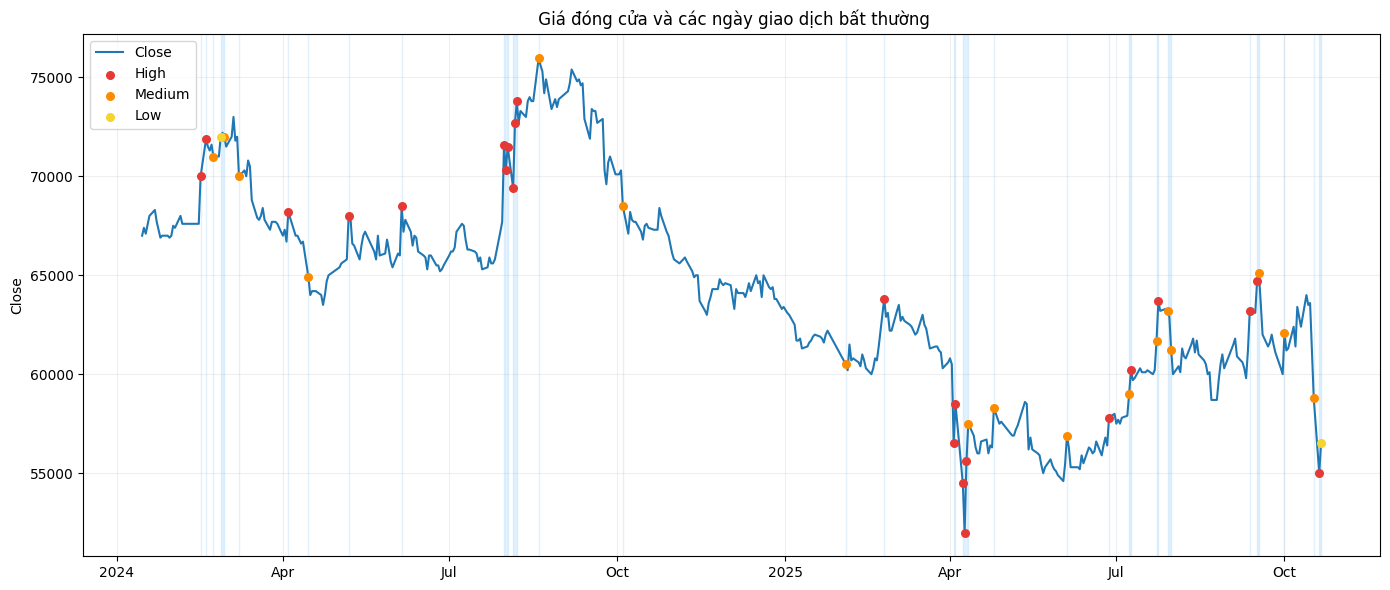

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============== Load data ==============
df = pd.read_csv("df_final_output.csv")
clu = pd.read_csv("clusters.csv") if True else pd.DataFrame()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Helpers
def severity_color(s):
    if s == 'High': return '#e53935'   # red
    if s == 'Medium': return '#fb8c00' # orange
    if s == 'Low': return '#f6d32d'    # yellow
    return '#9e9e9e'                   # grey for Normal

# ============== 1) Price + anomaly marks + cluster shading ==============
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df['Date'], df['Close'], lw=1.5, label='Close')

# Shade clusters if available
if not clu.empty:
    clu['start_date'] = pd.to_datetime(clu['start_date'])
    clu['end_date']   = pd.to_datetime(clu['end_date'])
    for _, r in clu.iterrows():
        ax.axvspan(r['start_date'], r['end_date'], color='#90caf9', alpha=0.25)

# Mark anomalies by severity
for sev in ['High','Medium','Low']:
    m = (df['label']=='Yes') & (df['severity']==sev)
    ax.scatter(df.loc[m,'Date'], df.loc[m,'Close'], s=30, color=severity_color(sev), label=sev, zorder=3)

ax.set_title(' Giá đóng cửa và các ngày giao dịch bất thường')
ax.set_ylabel('Close')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig('fig_price_anomalies.png', dpi=150)




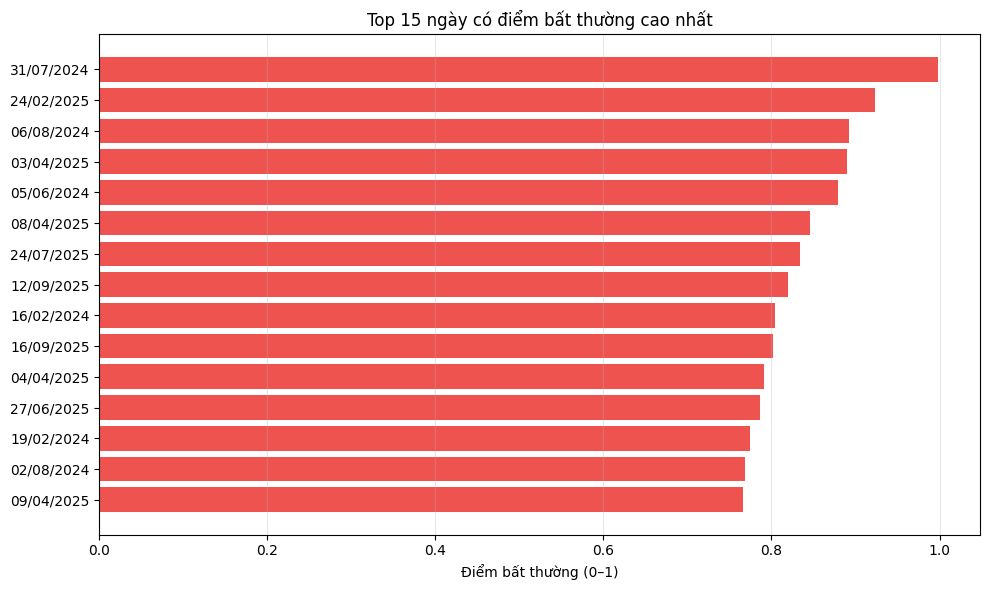

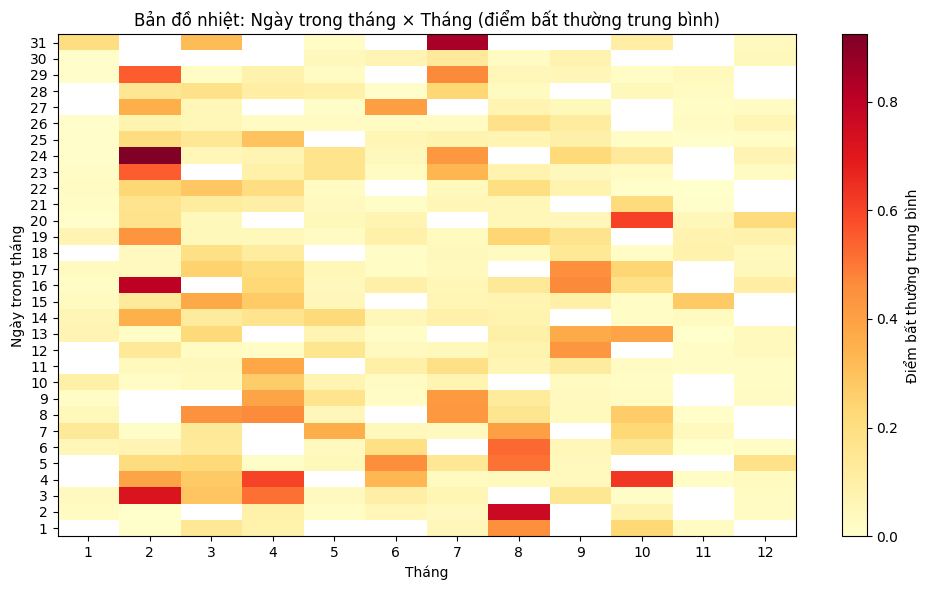

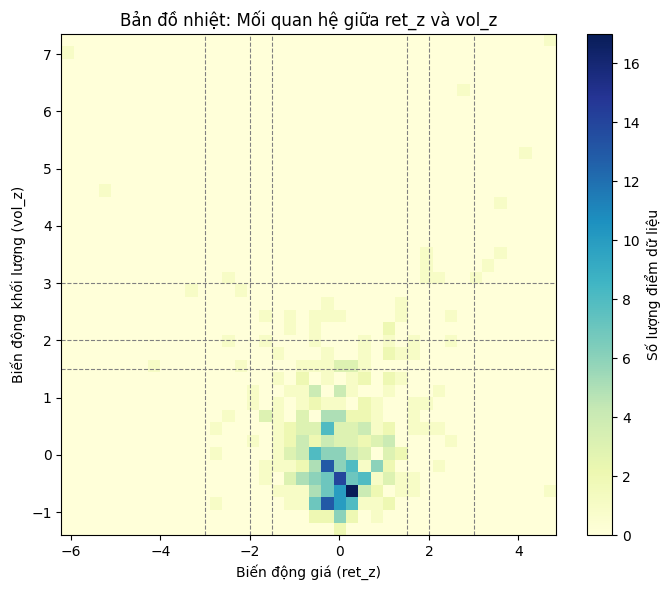

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============= Nạp dữ liệu =============
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Thử nạp file cụm
try:
    clu = pd.read_csv("clusters.csv")
    has_clusters = True
except FileNotFoundError:
    clu = pd.DataFrame()
    has_clusters = False


# ============= 3) Biểu đồ cột ngang: Top 15 ngày bất thường nhất =============
topn = (df.sort_values('anomaly_score', ascending=False)
          .head(15)
          .sort_values('anomaly_score'))
labels = topn['Date'].dt.strftime('%d/%m/%Y')

plt.figure(figsize=(10,6))
plt.barh(labels, topn['anomaly_score'].values, color='#ef5350')
plt.title('Top 15 ngày có điểm bất thường cao nhất')
plt.xlabel('Điểm bất thường (0–1)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('bieudo_top15_ngay.png', dpi=150)
plt.show()

# ============= 4) Heatmap lịch: Ngày trong tháng × Tháng =============
cal = df.copy()
cal['Tháng'] = cal['Date'].dt.month
cal['Ngày']   = cal['Date'].dt.day
pivot = cal.pivot_table(index='Ngày', columns='Tháng', values='anomaly_score', aggfunc='mean')

plt.figure(figsize=(10,6))
plt.imshow(pivot.values, aspect='auto', origin='lower', cmap='YlOrRd')
plt.colorbar(label='Điểm bất thường trung bình')
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.title('Bản đồ nhiệt: Ngày trong tháng × Tháng (điểm bất thường trung bình)')
plt.xlabel('Tháng'); plt.ylabel('Ngày trong tháng')
plt.tight_layout()
plt.savefig('heatmap_lich_bat_thuong.png', dpi=150)
plt.show()

# ============= 5) Heatmap 2D: ret_z vs vol_z =============
x = df['ret_z'].values
y = df['vol_z'].values

plt.figure(figsize=(7,6))
plt.hist2d(x, y, bins=40, cmap='YlGnBu')
plt.colorbar(label='Số lượng điểm dữ liệu')
for thr in [1.5, 2, 3]:
    plt.axvline(thr, ls='--', lw=0.8, color='gray')
    plt.axvline(-thr, ls='--', lw=0.8, color='gray')
    plt.axhline(thr, ls='--', lw=0.8, color='gray')
plt.xlabel('Biến động giá (ret_z)')
plt.ylabel('Biến động khối lượng (vol_z)')
plt.title('Bản đồ nhiệt: Mối quan hệ giữa ret_z và vol_z')
plt.tight_layout()
plt.savefig('heatmap_retZ_volZ.png', dpi=150)
plt.show()




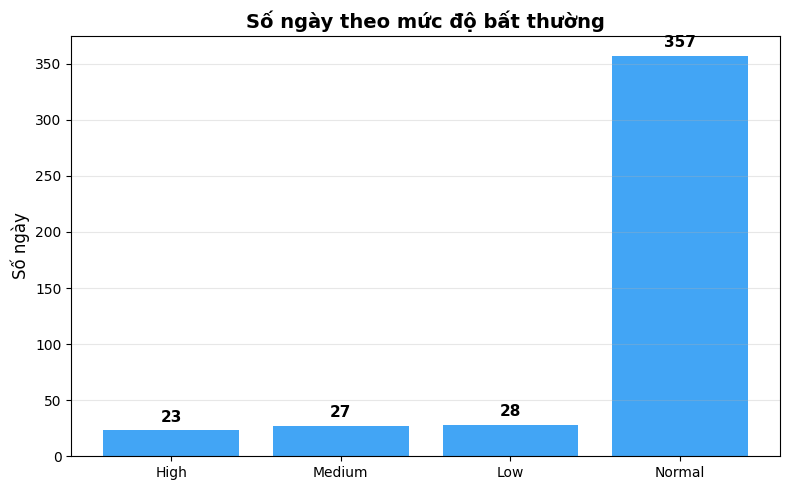

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Nạp dữ liệu
df = pd.read_csv("df_final_output.csv")

# Tính số lượng từng mức độ
severity_counts = df['severity'].value_counts().reindex(['High','Medium','Low','Normal'], fill_value=0)

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
bars = plt.bar(severity_counts.index, severity_counts.values, color='#42a5f5')

# Thêm nhãn số lên trên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tiêu đề và nhãn trục
plt.title('Số ngày theo mức độ bất thường', fontsize=14, fontweight='bold')
plt.ylabel('Số ngày', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bieudo_muc_do_bat_thuong.png', dpi=150)
plt.show()


In [23]:
import pandas as pd
import numpy as np

# === 1. Nạp dữ liệu chính ===
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])
total_days = len(df)

# === 2. Thống kê số ngày bất thường ===
abnormal_df = df[df['label'] == 'Yes']
n_abnormal = len(abnormal_df)
pct_abnormal = n_abnormal / total_days * 100

# === 3. Đếm theo mức độ ===
sev_counts = abnormal_df['severity'].value_counts().reindex(['High','Medium','Low'], fill_value=0)
high_n, med_n, low_n = sev_counts['High'], sev_counts['Medium'], sev_counts['Low']

# === 4. Xác định loại bất thường (giá, khối lượng, hay cả hai) ===
def detect_type(row):
    cond_price = abs(row.get('ret_z',0)) >= 1.8
    cond_vol   = row.get('vol_z',0) >= 1.8
    if cond_price and cond_vol: return "Giá + Khối lượng"
    elif cond_price: return "Giá"
    elif cond_vol: return "Khối lượng"
    else: return "Bình thường"

df['loai_bat_thuong'] = df.apply(detect_type, axis=1)

# === 5. Đếm số ngày liên tiếp có label Yes (để giống cột “so_ngay_lien_tiep”) ===
df = df.sort_values('Date').reset_index(drop=True)
df['group'] = (df['label'] != df['label'].shift()).cumsum()
df['so_ngay_lien_tiep'] = df.groupby('group')['label'].transform(lambda x: len(x) if x.iloc[0]=='Yes' else 0)

# === 6. Tạo bảng tóm tắt dạng giống hình bạn gửi ===
table = df[df['label']=='Yes'][['Date','loai_bat_thuong','severity','so_ngay_lien_tiep']].copy()
table.rename(columns={'severity':'anomaly_level'}, inplace=True)
table.reset_index(inplace=True)
table.index.name = 'Ticker'

# === 7. In ra kết quả ===
print("BẢNG KẾT QUẢ THỐNG KÊ CÁC NGÀY BẤT THƯỜNG")
print(f"Tổng số ngày bất thường: {n_abnormal} ({pct_abnormal:.2f}% dữ liệu)\n")
display(table.head(10))

print("\nTỔNG HỢP BẤT THƯỜNG:")
print(f"- Tổng số ngày bất thường: {n_abnormal}")
print(f"   • High  : {high_n} ngày")
print(f"   • Medium: {med_n} ngày")
print(f"   • Low   : {low_n} ngày")
print(f"- Tỷ lệ ngày bất thường: {pct_abnormal:.2f}% trên toàn bộ dữ liệu")

# === 8. Kết luận sơ bộ ===
avg_vol_z = df['vol_z'].mean()
avg_ret_std = df['return'].std()

if avg_vol_z < 1.2 and avg_ret_std < 0.015:
    conclusion = "Cổ phiếu ổn định – khó có khả năng thao túng."
elif high_n > 20 or pct_abnormal > 25:
    conclusion = "Có dấu hiệu thao túng đáng kể."
elif pct_abnormal > 12 or high_n > 10:
    conclusion = "Có thể có thao túng, cần kiểm tra thêm."
else:
    conclusion = "Chưa phát hiện dấu hiệu thao túng rõ ràng."

print(f"\nKẾT LUẬN: {conclusion}")



BẢNG KẾT QUẢ THỐNG KÊ CÁC NGÀY BẤT THƯỜNG
Tổng số ngày bất thường: 42 (9.66% dữ liệu)



,index,Date,loai_bat_thuong,anomaly_level,so_ngay_lien_tiep
Ticker,,,,,
0,18,2024-02-16,Giá + Khối lượng,High,2
1,19,2024-02-19,Giá + Khối lượng,High,2
2,23,2024-02-23,Khối lượng,Medium,1
3,25,2024-02-27,Bình thường,Low,1
4,27,2024-02-29,Khối lượng,Medium,1
5,33,2024-03-08,Giá + Khối lượng,Medium,1
6,52,2024-04-04,Giá + Khối lượng,High,1
7,59,2024-04-15,Giá,Medium,1
8,71,2024-05-07,Giá + Khối lượng,High,1



TỔNG HỢP BẤT THƯỜNG:
- Tổng số ngày bất thường: 42
   • High  : 23 ngày
   • Medium: 17 ngày
   • Low   : 2 ngày
- Tỷ lệ ngày bất thường: 9.66% trên toàn bộ dữ liệu

KẾT LUẬN: Cổ phiếu ổn định – khó có khả năng thao túng.
